In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.stats import linregress

In [3]:
deepcsa_run_dir = '/data/bbg/nobackup2/prominent/duplex_seq_tests/error_rate/cord_blood/bbg/deepCSA/2026-06-26_deepUMIcaller_and_dupcaller_4_paper'

## Indels comparisons

### Indel mutation density

In [4]:
mutation_densities = pd.read_table(f"{deepcsa_run_dir}/mutdensity/all_mutdensities.tsv")
mutation_densities["Caller"] = mutation_densities["SAMPLE_ID"].apply(lambda x: "DupCaller" if "dupcaller" in x.lower() else "deepUMIcaller")
mutation_densities.head()

,SAMPLE_ID,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSDENSITY_MB,MUTREADSDENSITY_MB_ADJUSTED,Caller
0,MethodIdt_CallerDeepumicaller,ALL_GENES,non_protein_affecting,all_types,5180177525,81.0,85.0,0.015637,0.017651,0.016409,0.018523,deepUMIcaller
1,MethodIdt_CallerDeepumicaller,ALL_GENES,non_protein_affecting,SNV,5180177525,75.0,79.0,0.014478,0.016344,0.015250,0.017215,deepUMIcaller
2,MethodIdt_CallerDeepumicaller,ALL_GENES,non_protein_affecting,DELETION-INSERTION,5180177525,6.0,6.0,0.001158,0.001307,0.001158,0.001307,deepUMIcaller
3,MethodIdt_CallerDeepumicaller,ALL_GENES,non_protein_affecting,DELETION-INSERTION-SNV,5180177525,81.0,85.0,0.015637,0.017651,0.016409,0.018523,deepUMIcaller
4,MethodIdt_CallerDeepumicaller,ACVR2A,non_protein_affecting,all_types,14724295,0.0,0.0,0.000000,0.000000,0.000000,0.000000,deepUMIcaller


In [5]:
mutation_type = 'indels'
samples_of_interest = ["SC003_B1_1_H_2", "SC002_B1_1_H_2", "SC001_B1_1_H_2",
                       "SC003_B1_1_H_2_dupcaller", "SC002_B1_1_H_2_dupcaller", "SC001_B1_1_H_2_dupcaller"
                       ]

upd_samples_of_interest = [
    "SC001_B1_1_H_2", "SC001_B1_1_H_2_DC",
    "SC002_B1_1_H_2", "SC002_B1_1_H_2_DC", 
    "SC003_B1_1_H_2", "SC003_B1_1_H_2_DC",
    ]


mutation_densities_of_interest = mutation_densities[
    (mutation_densities["MUTTYPES"] == 'DELETION-INSERTION')
    # (mutation_densities["MUTTYPES"] == 'SNV')
    & (mutation_densities["SAMPLE_ID"].isin(samples_of_interest))
    & (mutation_densities["REGIONS"].isin(["all"]))
    & (mutation_densities["GENE"].isin(["ALL_GENES"]))
].copy()
mutation_densities_of_interest["SAMPLE"] = mutation_densities_of_interest["SAMPLE_ID"].apply(lambda x: x.replace("_dupcaller", ""))
mutation_densities_of_interest = mutation_densities_of_interest.sort_values(by=["SAMPLE", "Caller"])
mutation_densities_of_interest


,SAMPLE_ID,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSDENSITY_MB,MUTREADSDENSITY_MB_ADJUSTED,Caller,SAMPLE
10386,SC001_B1_1_H_2_dupcaller,ALL_GENES,all,DELETION-INSERTION,2211812690,13.0,13.0,0.005878,0.005878,0.005878,0.005878,DupCaller,SC001_B1_1_H_2
69346,SC001_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,2145974912,10.0,10.0,0.004660,0.004660,0.004660,0.004660,deepUMIcaller,SC001_B1_1_H_2
59978,SC002_B1_1_H_2_dupcaller,ALL_GENES,all,DELETION-INSERTION,2869620914,7.0,7.0,0.002439,0.002439,0.002439,0.002439,DupCaller,SC002_B1_1_H_2
37898,SC002_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,2780980595,6.0,6.0,0.002158,0.002158,0.002158,0.002158,deepUMIcaller,SC002_B1_1_H_2
41538,SC003_B1_1_H_2_dupcaller,ALL_GENES,all,DELETION-INSERTION,3955477901,9.0,25.0,0.002275,0.002275,0.006320,0.006320,DupCaller,SC003_B1_1_H_2
66482,SC003_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,3829251123,6.0,6.0,0.001567,0.001567,0.001567,0.001567,deepUMIcaller,SC003_B1_1_H_2


In [6]:
mutation_densities_of_interest.sort_values(by=["SAMPLE", "Caller"])[["DEPTH", "N_MUTS", "MUTDENSITY_MB"]] #, "SAMPLE", "Caller"]]

,DEPTH,N_MUTS,MUTDENSITY_MB
10386,2211812690,13.0,0.005878
69346,2145974912,10.0,0.004660
59978,2869620914,7.0,0.002439
37898,2780980595,6.0,0.002158
41538,3955477901,9.0,0.002275
66482,3829251123,6.0,0.001567


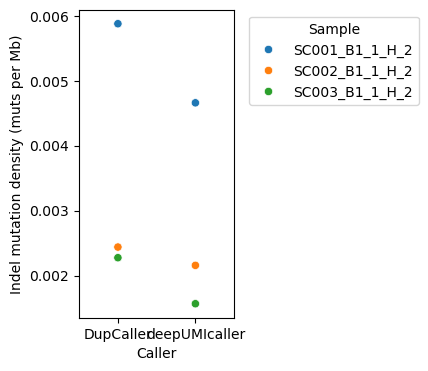

In [7]:
plt.figure(figsize=(2, 4))
sns.scatterplot(data=mutation_densities_of_interest,
                x="Caller", y="MUTDENSITY_MB",
                hue="SAMPLE")
plt.xlim(-0.5, 1.5)
plt.xlabel("Caller")
plt.ylabel("Indel mutation density (muts per Mb)")
plt.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.savefig("../plots/indel_mutation_density_comparison.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [8]:

# --- Error rate plot --------------------------------------------------------
from zipfile import Path

from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter


def plot_error_rate(mutrate: pd.DataFrame, samples: list, outdir: Path, protocol_order: list, ylim: float = 1e-8):
    """
    Plot error rate for all samples (deepUMIcaller + DupCaller).
    Bars whose protocol is 'corrected' or 'uncorrected' are drawn as outlines only (no fill).
    ALT samples are separated from the rest by a broken x-axis gap.
    """
    UNFILLED_PROTOCOLS = {'corrected', 'uncorrected'}
    ALT_GAP = 0.8  # extra x-space inserted before the first ALT bar

    colors = dict(zip(protocol_order, sns.color_palette('muted')))
    colors["deepUMIcaller"] = colors["DupCaller"]

    sample_rows = {}
    for s in samples:
        match = mutrate[mutrate['sample'] == s]
        if not match.empty:
            sample_rows[s] = match.iloc[0]

    # --- Compute custom x positions (gap before first ALT bar) -------------
    x_positions = []
    gap_added = False
    alt_start_idx = None
    x = 0
    for idx, sample in enumerate(samples):
        row = sample_rows.get(sample)
        if row is not None and row['protocol'] == 'ALT' and not gap_added:
            x += ALT_GAP
            gap_added = True
            alt_start_idx = idx
        x_positions.append(x)
        x += 1

    x_min = -0.5
    x_max = x_positions[-1] + 0.5

    fig, ax = plt.subplots(figsize=(4.5, 2.5))

    for x_pos, sample in zip(x_positions, samples):
        row = sample_rows.get(sample)
        if row is None:
            continue
        color       = colors.get(row['protocol'], 'gray')
        is_dc       = '_DC' in sample  # Add hatch for DupCaller samples
        is_unfilled = False
        yerr_lo     = row['mutrate_observed'] - row['mutrate_CI_low']
        yerr_hi     = row['mutrate_CI_high']  - row['mutrate_observed']

        ax.bar(
            x_pos, row['mutrate_observed'],
            color     = 'none' if is_unfilled else color,
            hatch     = '//' if (is_dc and not is_unfilled) else '',
            edgecolor = color if is_unfilled else ('white' if is_dc else color),
            linewidth = 1.5 if is_unfilled else 0.5,
            width     = 0.7,
        )
        ax.errorbar(
            x_pos, row['mutrate_observed'],
            yerr=[[yerr_lo], [yerr_hi]],
            fmt='none', ecolor='black', capsize=3, lw=0.8,
        )

    # ax.axhline(y=2e-8, color='red', linestyle='--',
    #            label='Expected mutations', linewidth=0.5)
    # ax.axhline(y=1e-8, color='red', linestyle='--', linewidth=0.5)

    # y-axis
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(fmt)

    sns.despine(ax=ax, top=True, right=True)
    ax.set_xlabel('')
    ax.set_ylabel('Indels per bp')
    ax.set_title('Cord blood DNA')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(samples, rotation=45, ha='right', fontsize=7)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, ylim)

    # --- Broken x-axis spine -----------------------------------------------
    if alt_start_idx is not None:
        ax.spines['bottom'].set_visible(False) # Remove line
        total_width   = x_max - x_min 
        gap_start_ax  = (x_positions[alt_start_idx - 1] + 0.5 - x_min) / total_width
        gap_end_ax    = (x_positions[alt_start_idx]     - 0.5 - x_min) / total_width
        spine_lw = 0.8
        ax.add_line(plt.Line2D([0, gap_start_ax], [0, 0], # Add line to first part
                               transform=ax.transAxes, color='black',
                               linewidth=spine_lw, clip_on=False))
        ax.add_line(plt.Line2D([gap_end_ax, 1], [0, 0], # Add line to second part
                               transform=ax.transAxes, color='black',
                               linewidth=spine_lw, clip_on=False))

    # --- Legend ------------------------------------------------------------
    handles = []
    for p in protocol_order:
        if p not in colors or p == 'others':
            continue
        if p in UNFILLED_PROTOCOLS:
            continue
        else:
            handles.append(Patch(facecolor=colors[p], label=p))
    handles.append(Patch(facecolor=colors['DupCaller'], hatch='///', edgecolor='white',
                         label='DupCaller'))
    # handles.append(Patch(facecolor='none', edgecolor='gray', linewidth=1.5,
    #                      label='DupCaller report'))
    # handles.append(plt.Line2D([0], [0], color='red', linestyle='--',
    #                            linewidth=0.8, label='Expected mutations'))
    ax.legend(handles=handles, title='', frameon=False,
              bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=7)

    plt.subplots_adjust(bottom=0.35, right=0.75)
    plt.savefig(outdir,
                bbox_inches='tight', dpi=300)
    plt.show()


In [9]:
import pandas as pd
from scipy.stats import poisson


mutation_densities_of_interest_for_plot = mutation_densities_of_interest.copy()
mutation_densities_of_interest_for_plot["SAMPLE_ID"] = mutation_densities_of_interest_for_plot["SAMPLE_ID"].apply(lambda x: x.replace("_dupcaller", "_DC"))
mutation_densities_of_interest_for_plot = mutation_densities_of_interest_for_plot.rename(columns={"SAMPLE_ID": "sample",
                                                        "Caller": "protocol"
                                                        })

alpha = 0.05

lower, upper = poisson.interval(
    1 - alpha,
    mutation_densities_of_interest_for_plot["N_MUTS"]
)

mutation_densities_of_interest_for_plot["mutrate_observed"] = mutation_densities_of_interest_for_plot["N_MUTS"] / mutation_densities_of_interest_for_plot["DEPTH"]
mutation_densities_of_interest_for_plot["mutrate_CI_low"] = lower / mutation_densities_of_interest_for_plot["DEPTH"]
mutation_densities_of_interest_for_plot["mutrate_CI_high"] = upper / mutation_densities_of_interest_for_plot["DEPTH"]

mutation_densities_of_interest_for_plot

,sample,GENE,REGIONS,MUTTYPES,DEPTH,N_MUTS,N_MUTATED,MUTDENSITY_MB,MUTDENSITY_MB_ADJUSTED,MUTREADSDENSITY_MB,MUTREADSDENSITY_MB_ADJUSTED,protocol,SAMPLE,mutrate_observed,mutrate_CI_low,mutrate_CI_high
10386,SC001_B1_1_H_2_DC,ALL_GENES,all,DELETION-INSERTION,2211812690,13.0,13.0,0.005878,0.005878,0.005878,0.005878,DupCaller,SC001_B1_1_H_2,5.877532e-09,2.712707e-09,9.494475e-09
69346,SC001_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,2145974912,10.0,10.0,0.004660,0.004660,0.004660,0.004660,deepUMIcaller,SC001_B1_1_H_2,4.659887e-09,1.863955e-09,7.921807e-09
59978,SC002_B1_1_H_2_DC,ALL_GENES,all,DELETION-INSERTION,2869620914,7.0,7.0,0.002439,0.002439,0.002439,0.002439,DupCaller,SC002_B1_1_H_2,2.439347e-09,6.969562e-10,4.530215e-09
37898,SC002_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,2780980595,6.0,6.0,0.002158,0.002158,0.002158,0.002158,deepUMIcaller,SC002_B1_1_H_2,2.157512e-09,7.191708e-10,3.955439e-09
41538,SC003_B1_1_H_2_DC,ALL_GENES,all,DELETION-INSERTION,3955477901,9.0,25.0,0.002275,0.002275,0.006320,0.006320,DupCaller,SC003_B1_1_H_2,2.275326e-09,1.011256e-09,3.792209e-09
66482,SC003_B1_1_H_2,ALL_GENES,all,DELETION-INSERTION,3829251123,6.0,6.0,0.001567,0.001567,0.001567,0.001567,deepUMIcaller,SC003_B1_1_H_2,1.566886e-09,5.222953e-10,2.872624e-09


In [10]:
mutation_densities_of_interest_for_plot[["sample", "protocol", "N_MUTS","mutrate_observed", "mutrate_CI_low", "mutrate_CI_high"]]

,sample,protocol,N_MUTS,mutrate_observed,mutrate_CI_low,mutrate_CI_high
10386,SC001_B1_1_H_2_DC,DupCaller,13.0,5.877532e-09,2.712707e-09,9.494475e-09
69346,SC001_B1_1_H_2,deepUMIcaller,10.0,4.659887e-09,1.863955e-09,7.921807e-09
59978,SC002_B1_1_H_2_DC,DupCaller,7.0,2.439347e-09,6.969562e-10,4.530215e-09
37898,SC002_B1_1_H_2,deepUMIcaller,6.0,2.157512e-09,7.191708e-10,3.955439e-09
41538,SC003_B1_1_H_2_DC,DupCaller,9.0,2.275326e-09,1.011256e-09,3.792209e-09
66482,SC003_B1_1_H_2,deepUMIcaller,6.0,1.566886e-09,5.222953e-10,2.872624e-09


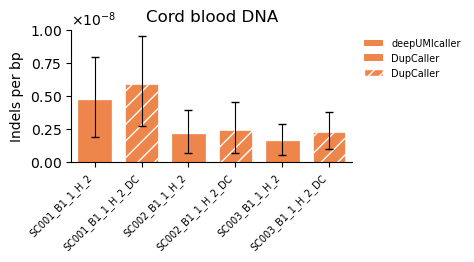

In [11]:
OUTDIR = '../plots/20260226_mutrate_indels.pdf'
plot_error_rate(mutrate=mutation_densities_of_interest_for_plot, samples=upd_samples_of_interest,
                outdir=OUTDIR,
                protocol_order=["deepUMIcaller", "DupCaller"])

In [12]:
mutations = pd.read_table(f"{deepcsa_run_dir}/mutations/germline_somatic/all_samples.filtered.tsv.gz")

/tmp/ipykernel_367205/1882221328.py:1: DtypeWarning: Columns (112) have mixed types. Specify dtype option on import or set low_memory=False.
  mutations = pd.read_table(f"{deepcsa_run_dir}/mutations/germline_somatic/all_samples.filtered.tsv.gz")


In [15]:
indels = mutations[mutations["TYPE"].isin(["DELETION", "INSERTION"])]

In [16]:
indels.groupby("SAMPLE_ID").size().reset_index(name="N_INDELS").sort_values(by="N_INDELS", ascending=False)

,SAMPLE_ID,N_INDELS
7,SC003_B1_2_H_2,3932
2,SC001_B1_2_H_2,3277
3,SC002_B1_1_H_2,1955
5,SC003_B1_1_H_2,1880
0,SC001_B1_1_H_2,1782
6,SC003_B1_1_H_2_dupcaller,458
4,SC002_B1_1_H_2_dupcaller,431
1,SC001_B1_1_H_2_dupcaller,364


In [23]:
indels_dupcaller = indels[indels["SAMPLE_ID"].isin(["SC003_B1_1_H_2_dupcaller", "SC002_B1_1_H_2_dupcaller", "SC001_B1_1_H_2_dupcaller"])]
indels_dupcaller = indels_dupcaller[~(indels_dupcaller["FILTER.nanoseq_noise"])]
indels_dupcaller

,CHROM,POS,REF,ALT,FILTER,INFO,FORMAT,SAMPLE,DEPTH,ALT_DEPTH,...,FILTER.not_covered,FILTER.not_in_exons,FILTER.not_searched_COMPLEX,FILTER.other_sample_SNP,FILTER.p10,FILTER.pSTD,FILTER.q22.5,FILTER.repetitive_mapping_variant,FILTER.repetitive_variant,FILTER.v1
142,chr1,11122204,G,GT,cohort_n_rich;cohort_n_rich_uni;gnomAD_SNP;nan...,SAMPLE=SC001_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:0:1:-1,1:inf:-1,0:0,1:0:-1,1:0:0:-1,1:0",0,1,...,True,True,False,False,False,False,False,False,False,False
145,chr1,11122204,G,GT,cohort_n_rich;cohort_n_rich_uni;gnomAD_SNP;nan...,SAMPLE=SC003_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:0:1:-1,1:inf:-1,0:0,1:0:-1,1:0:0:-1,1:0",0,1,...,True,True,False,False,False,False,False,False,False,False
1359,chr1,185171735,A,AT,gnomAD_SNP;nanoseq_snp;not_covered;not_in_exons,SAMPLE=SC001_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:0:1:-1,1:inf:-1,0:0,1:0:-1,1:0:0:-1,1:0",0,1,...,True,True,False,False,False,False,False,False,False,False
1581,chr1,240768145,GCTCTAGGTGTTTCCTGTGATCTCTGGGATCCTGAT,G,not_in_exons,SAMPLE=SC002_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:795:1:794,1:0.00126:397,397:0,1:795:794,1:...",795,1,...,False,True,False,False,False,False,False,False,False,False
1868,chr10,8058488,C,CG,PASS,SAMPLE=SC001_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:1587:1:1586,1:0.00063:793,793:0,1:1587:158...",1587,1,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34145,chr9,136507428,CGGCCACG,C,PASS,SAMPLE=SC002_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:2209:1:2208,1:0.00045:1104,1104:0,1:2209:2...",2209,1,...,False,False,False,False,False,False,False,False,False,False
34159,chr9,136508728,ATC,A,not_in_exons,SAMPLE=SC003_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:1461:1:1460,1:0.00068:730,730:0,1:1461:146...",1461,1,...,False,True,False,False,False,False,False,False,False,False
34438,chrX,40072629,CCCAGA,C,PASS,SAMPLE=SC003_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:2044:1:2043,1:0.00049:1021,1022:0,1:2044:2...",2044,1,...,False,False,False,False,False,False,False,False,False,False
34500,chrX,41346270,GGT,G,PASS,SAMPLE=SC001_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:855:1:854,1:0.00117:427,427:0,1:855:854,1:...",855,1,...,False,False,False,False,False,False,False,False,False,False


In [25]:
indels_dupcaller["FILTER"].value_counts()


FILTER
cohort_n_rich;cohort_n_rich_uni;gnomAD_SNP;nanoseq_snp;not_covered;not_in_exons                                                  16
not_in_exons                                                                                                                     15
cohort_n_rich;cohort_n_rich_uni;gnomAD_SNP;nanoseq_snp;not_covered;repetitive_variant                                            13
PASS                                                                                                                             11
gnomAD_SNP;nanoseq_snp;not_covered;not_in_exons                                                                                  10
cohort_n_rich;cohort_n_rich_uni;gnomAD_SNP;nanoseq_snp;not_covered;not_in_exons;repetitive_variant                                7
nanoseq_snp;not_covered                                                                                                           4
cohort_n_rich_uni;not_in_exons                                       

In [28]:
indels_dupcaller[indels_dupcaller["DEPTH"]>10]
# indels_dupcaller[["MUT_ID", "SAMPLE_ID", "FILTER", "DEPTH", "ALT_DEPTH"]]

,CHROM,POS,REF,ALT,FILTER,INFO,FORMAT,SAMPLE,DEPTH,ALT_DEPTH,...,FILTER.not_covered,FILTER.not_in_exons,FILTER.not_searched_COMPLEX,FILTER.other_sample_SNP,FILTER.p10,FILTER.pSTD,FILTER.q22.5,FILTER.repetitive_mapping_variant,FILTER.repetitive_variant,FILTER.v1
1581,chr1,240768145,GCTCTAGGTGTTTCCTGTGATCTCTGGGATCCTGAT,G,not_in_exons,SAMPLE=SC002_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:795:1:794,1:0.00126:397,397:0,1:795:794,1:...",795,1,...,False,True,False,False,False,False,False,False,False,False
1868,chr10,8058488,C,CG,PASS,SAMPLE=SC001_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:1587:1:1586,1:0.00063:793,793:0,1:1587:158...",1587,1,...,False,False,False,False,False,False,False,False,False,False
2707,chr10,113151910,AGCGGGGG,A,not_in_exons,SAMPLE=SC002_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:2082:1:2081,1:0.00048:1040,1041:0,1:2082:2...",2082,1,...,False,True,False,False,False,False,False,False,False,False
2959,chr10,121551678,G,GA,cohort_n_rich;cohort_n_rich_uni;nanoseq_snp;no...,SAMPLE=SC001_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:242:2:240,2:0.00826:120,120:1,1:242:240,2:...",242,2,...,True,True,False,False,False,False,False,False,True,False
2968,chr10,121551678,G,GA,cohort_n_rich;cohort_n_rich_uni;nanoseq_snp;no...,SAMPLE=SC003_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:308:1:307,1:0.00325:153,154:0,1:308:307,1:...",308,1,...,True,True,False,False,False,False,False,False,True,False
3422,chr11,92765162,AAG,A,not_covered;not_in_exons,SAMPLE=SC001_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:1150:3:1147,3:0.00261:573,574:1,2:1150:114...",1150,3,...,True,True,False,False,False,False,False,False,False,False
3885,chr11,108292594,TTG,T,not_in_exons,SAMPLE=SC001_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:872:1:871,1:0.00115:435,436:0,1:872:871,1:...",872,1,...,False,True,False,False,False,False,False,False,False,False
4344,chr11,118504578,CT,C,PASS,SAMPLE=SC003_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:4081:1:4080,1:0.00025:2040,2040:0,1:4081:4...",4081,1,...,False,False,False,False,False,False,False,False,False,False
4556,chr12,6581021,A,AAAC,not_in_exons,SAMPLE=SC003_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:3155:17:3138,17:0.00539:1569,1569:8,9:3155...",3155,17,...,False,True,False,False,False,False,False,False,False,False
10227,chr16,72951030,AC,A,not_in_exons,SAMPLE=SC003_B1_1_H_2_dupcaller;,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:CDPAM:CADAM:...,"0/1:2147:1:2146,1:0.00047:1073,1073:0,1:2147:2...",2147,1,...,False,True,False,False,False,False,False,False,False,False
